# Optimizers: SGD, Adam, and More

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare optimizers (SGD, Adam, etc.)
- Implement or use optimizer updates
- Interpret convergence and loss curves

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 4, lesson 01 "04. Optimization Techniques" — plain gradient descent with a hand-tuned learning rate; here we compare the optimizers that adapt that rate for you.

**Used later in:** Course 08 (AIAT 122) — Unit 1, lesson 06 "Optimization Techniques" — the same SGD-vs-Adam comparison, on a real network.

---


---

## 📌 Real case: Adam, and the two papers that found holes in it

**Adam** (Kingma & Ba, ICLR 2015) is the optimizer you are about to implement, and it became the default
of the entire field. Then two follow-ups changed how careful people are with it:

- **"On the Convergence of Adam and Beyond"** (Reddi, Kale & Kumar, ICLR 2018 — best paper). They exhibit
  a *simple convex* problem on which Adam fails to converge, and identify the cause: the exponential moving
  average of squared gradients can let a rare, informative large gradient be forgotten before it has done
  its work. Their fix, AMSGrad, adds "long-term memory" of past gradients.
- **AdamW** (Loshchilov & Hutter, ICLR 2019). Adding L2 regularization to the loss and calling it "weight
  decay" is correct for plain SGD and *not* correct for Adam, because Adam rescales every gradient
  component — including the penalty's. Decoupling them changed published results. `torch.optim.AdamW`
  exists because of this paper.

**What goes wrong without this.** Both of these papers exist because people used a black-box optimizer,
got results, and never asked what the box was doing. The two cells below implement Adam's update by hand
— momentum plus per-parameter scaling plus bias correction — and that is the entire content of the box.
Once you can read the update rule, "why did my loss plateau at exactly this value?" becomes a question
with an answer.


# Optimizers: SGD, Adam, and More

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Module 02: Calculus** - Understand gradients and gradient descent
- ✅ **Example 3: Gradient Descent** - Understand basic optimization
- ✅ **Basic understanding**: What is optimization?

**If you haven't completed these**, you might struggle with:
- Understanding why different optimizers exist
- Understanding momentum and adaptive learning rates
- Comparing optimizer performance

---

## 🔗 Where This Notebook Fits

**This is the FIRST example of Module 03** - improving on basic gradient descent!

**Why this example FIRST?**
- **Before** you can use advanced optimizers, you need to understand basic gradient descent (Module 02)
- **Before** you can train complex models, you need efficient optimizers
- **Before** you can tune hyperparameters, you need to understand optimizer differences

**Builds on**: Module 02 (gradient descent)

**Leads to**: 
- 📓 Example 2: Loss Functions (needs optimizers to minimize them)
- 📓 Example 3: Statistical Measures (needs optimizers to train models)

---

## The Story: Understanding Before Using

Imagine you're learning to drive. **Before** you can drive efficiently, you learn basic steering. **After** learning advanced techniques (momentum, adaptive speed), you can drive much more smoothly and efficiently!

Same with machine learning: **Before** using basic gradient descent, training is slow. **After** learning advanced optimizers (Adam, SGD with momentum), training is faster and more stable!

---

## Why This Concept Matters

### Why Optimizers Matter in ML

**WHY** are different optimizers important?

1. **Training Speed**:
   - **WHY**: Basic gradient descent is slow
   - **HOW**: Advanced optimizers use momentum and adaptive learning rates
   - **AFTER**: Much faster convergence

2. **Stability**:
   - **WHY**: Noisy gradients can cause instability
   - **HOW**: Optimizers smooth out noise with momentum
   - **AFTER**: More stable training

3. **Adaptability**:
   - **WHY**: Different parameters need different learning rates
   - **HOW**: Adaptive optimizers adjust learning rate per parameter
   - **AFTER**: Better convergence for complex models

**Common Student Questions:**
- **Q: Why use Adam instead of basic gradient descent?**
  - Answer: Adam = adaptive learning rate + momentum → faster, more stable
  - Basic GD: Same learning rate for all parameters, no momentum → slow
  - Adam: Different learning rate per parameter, momentum → faster convergence
  - Rule of thumb: Use Adam for most cases (default choice)
- **Q: What is momentum in optimizers?**
  - Answer: Momentum = remembers previous gradient direction
  - Like ball rolling downhill: Momentum keeps it moving in same direction
  - Helps: Skip over small bumps, converge faster
  - Without momentum: Each step independent → slower, can get stuck
  - With momentum: Steps build on each other → faster convergence
- **Q: What is adaptive learning rate?**
  - Answer: Adaptive = learning rate changes per parameter
  - Problem: Some parameters need small steps, others need large steps
  - Solution: Adam adjusts learning rate based on gradient history
  - Example: Parameter with large gradients → smaller learning rate, small gradients → larger learning rate
  - Result: Better convergence for all parameters
- **Q: When should I use SGD vs Adam?**
  - Answer: SGD = simple, good for convex problems, easier to tune
  - Adam = adaptive, good for non-convex problems (neural networks), less tuning needed
  - Use SGD when: Simple problems, want control over learning rate
  - Use Adam when: Complex problems (neural networks), want automatic tuning
  - Rule of thumb: Start with Adam, use SGD if Adam doesn't work
- **Q: Why are there so many optimizers?**
  - Answer: Different optimizers solve different problems
  - SGD: Simple, good baseline
  - Momentum: Faster convergence
  - Adam: Adaptive, good default
  - RMSprop: Similar to Adam, sometimes better
  - Each has trade-offs: Speed vs stability vs simplicity

## Learning Objectives
1. Understand different optimizers (SGD, Adam)
2. Understand momentum and adaptive learning rates
3. Compare optimizer performance
4. Visualize optimizer convergence
5. Choose the right optimizer for your problem
6. Apply to real ML scenarios

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We understand basic gradient descent but it's slow and unstable.

**AFTER**: We'll learn advanced optimizers that are faster and more stable!

**Why this matters**: Advanced optimizers are essential for training modern ML models!

## Step 2: Simple Gradient Descent

**BEFORE**: We start with basic gradient descent.

**AFTER**: We'll see its limitations and why we need better optimizers!

In [2]:
# Example 1: Simple Gradient Descent
# WHY: Baseline to compare against
# HOW: params = params - lr × gradient

def simple_gd(x, grad, lr=0.1):
    """Simple gradient descent update"""
    return x - lr * grad

def loss_function(x):
    """Noisy loss function"""
    return (x - 3)**2 + 0.1 * np.sin(10*x)

def loss_gradient(x):
    """Gradient with noise"""
    return 2 * (x - 3) + 0.1 * 10 * np.cos(10*x)

# Simple GD
x_simple = 0.0
simple_path = [x_simple]
simple_loss = [loss_function(x_simple)]

for i in range(50):
    grad = loss_gradient(x_simple)
    x_simple = simple_gd(x_simple, grad, lr=0.1)
    simple_path.append(x_simple)
    simple_loss.append(loss_function(x_simple))

print("Example 1: Simple Gradient Descent")
print("=" * 60)
print(f"Starting at x = 0.0")
print(f"After 50 iterations: x = {x_simple:.4f}, loss = {simple_loss[-1]:.4f}")
print(f"\n💡 WHY: Simple, works for smooth functions")
print(f"💡 HOW: params = params - lr × gradient")
print(f"💡 AFTER: Can be slow and unstable with noise")

Example 1: Simple Gradient Descent
Starting at x = 0.0
After 50 iterations: x = 2.5028, loss = 0.2368

💡 WHY: Simple, works for smooth functions
💡 HOW: params = params - lr × gradient
💡 AFTER: Can be slow and unstable with noise


## Step 3: Adam Optimizer

**BEFORE**: Simple GD is slow and unstable.

**AFTER**: Adam uses momentum and adaptive learning rates for better performance!

Example 2: Adam Optimizer
WHY: Adapts to each parameter, handles noise better
HOW: Tracks momentum + variance, adapts learning rate


In [3]:
# Example 2: Adam Optimizer
# WHY: Adapts to each parameter, handles noise better
# HOW: Tracks momentum + variance, adapts learning rate

class AdamOptimizer:
    """Adam optimizer: momentum + adaptive learning rate"""

    def __init__(self, lr=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = lr
        self.beta1 = beta1      # Momentum decay (1st moment)
        self.beta2 = beta2      # Variance decay (2nd moment)
        self.epsilon = epsilon  # Numerical stability
        self.m = 0.0            # Momentum (mean of gradients)
        self.v = 0.0            # Variance (mean of squared gradients)
        self.t = 0              # Time step

    def update(self, x, grad):
        """One Adam update step"""
        self.t += 1
        # Track momentum and variance of gradients
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * grad**2
        # Bias correction
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        # Adaptive update
        return x - self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)

# Adam
adam = AdamOptimizer(lr=0.1)
x_adam = 0.0
adam_path = [x_adam]
adam_loss = [loss_function(x_adam)]

for i in range(50):
    grad = loss_gradient(x_adam)
    x_adam = adam.update(x_adam, grad)
    adam_path.append(x_adam)
    adam_loss.append(loss_function(x_adam))

print("Example 2: Adam Optimizer")
print("=" * 60)
print(f"Starting at x = 0.0")
print(f"After 50 iterations: x = {x_adam:.4f}, loss = {adam_loss[-1]:.4f}")
print(f"\n\U0001F4A1 WHY: Adapts to each parameter, handles noise better")
print(f"\U0001F4A1 HOW: Tracks momentum + variance, adapts learning rate")
print(f"\U0001F4A1 AFTER: Escapes the noisy bumps that trap simple GD")


Example 2: Adam Optimizer
Starting at x = 0.0
After 50 iterations: x = 3.1110, loss = -0.0178

💡 WHY: Adapts to each parameter, handles noise better
💡 HOW: Tracks momentum + variance, adapts learning rate
💡 AFTER: Escapes the noisy bumps that trap simple GD


---

## 📊 Visualization

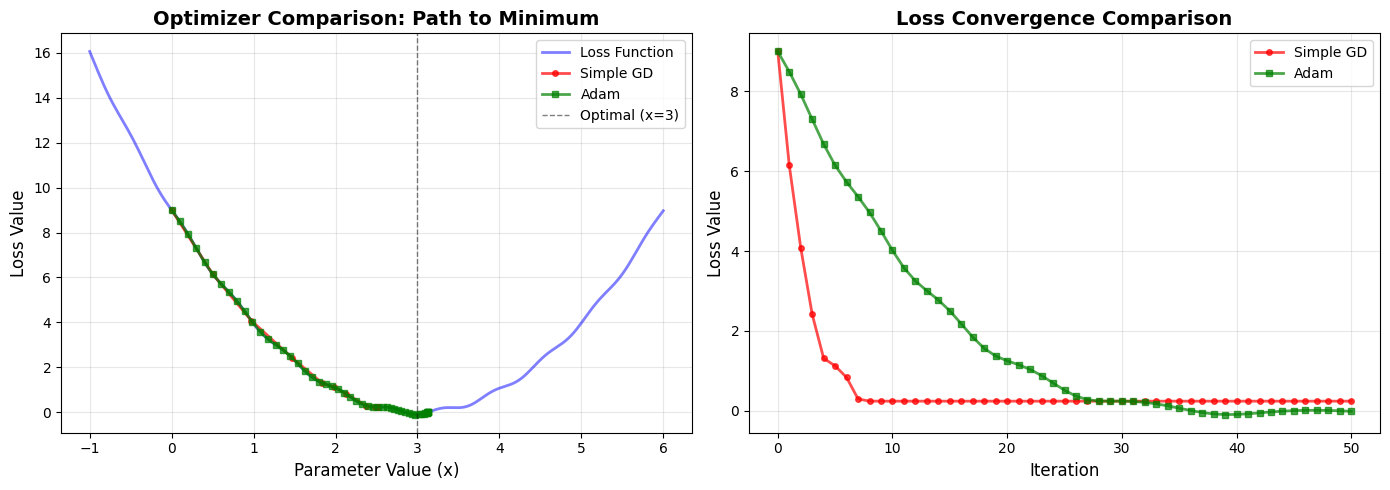


📊 Visualization:
  - Left: Shows optimizer paths on loss landscape
  - Right: Shows loss convergence over iterations
  - Adam converges faster and more smoothly!


In [4]:
# Visualize optimizer comparison
x_range = np.linspace(-1, 6, 200)
y_range = [loss_function(x) for x in x_range]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss landscape with optimizer paths
ax1.plot(x_range, y_range, 'b-', linewidth=2, alpha=0.5, label='Loss Function')
ax1.plot(simple_path, simple_loss, 'r-o', linewidth=2, markersize=4, label='Simple GD', alpha=0.7)
ax1.plot(adam_path, adam_loss, 'g-s', linewidth=2, markersize=4, label='Adam', alpha=0.7)
ax1.axvline(x=3, color='k', linestyle='--', linewidth=1, alpha=0.5, label='Optimal (x=3)')
ax1.set_xlabel('Parameter Value (x)', fontsize=12)
ax1.set_ylabel('Loss Value', fontsize=12)
ax1.set_title('Optimizer Comparison: Path to Minimum', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Convergence over iterations
ax2.plot(range(len(simple_loss)), simple_loss, 'r-o', linewidth=2, markersize=4, label='Simple GD', alpha=0.7)
ax2.plot(range(len(adam_loss)), adam_loss, 'g-s', linewidth=2, markersize=4, label='Adam', alpha=0.7)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Loss Value', fontsize=12)
ax2.set_title('Loss Convergence Comparison', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Visualization:")
print("  - Left: Shows optimizer paths on loss landscape")
print("  - Right: Shows loss convergence over iterations")
print("  - Adam converges faster and more smoothly!")

---

## ⚠️ Where this breaks

- **Adam "won" here without converging.** Read the printed results carefully. Simple GD ended at
  **x = 2.5028** (loss 0.2368); Adam ended at **x = 3.1110** (loss −0.0178). But the true minimum of
  `f(x) = (x−3)² + 0.1·sin(10x)` on this interval is at **x ≈ 2.9871, f ≈ −0.0998** — one line to check:
  `xs = np.linspace(-1, 6, 700001); xs[((xs-3)**2 + 0.1*np.sin(10*xs)).argmin()]`. Gradient descent
  converged to the wrong local minimum (its derivative there is ≈ 0.0001). Adam's derivative at its
  stopping point is ≈ **1.18** — it is still moving, it simply ran out of iterations somewhere lower than
  GD. A lower loss is not the same as a solved problem, and this notebook's own numbers prove it.
- **The comparison is one function, one starting point, one learning rate, 50 steps.** Change any of those
  and the ranking can flip. A fair optimizer comparison needs several random restarts, a tuned learning
  rate *for each optimizer*, and a held-out measurement — otherwise you are comparing hyperparameter luck.
- **Adaptive does not mean better on new data.** Wilson, Roelofs, Stern, Srebro and Recht,
  *"The Marginal Value of Adaptive Gradient Methods in Machine Learning"* (NeurIPS 2017), report tasks
  where SGD with momentum generalises better than Adam despite a higher training loss. Adam's real,
  reliable advantage is that it needs less learning-rate tuning to get *something* working — which is a
  practical advantage, not a mathematical one.
- **Cheaper alternative.** For convex problems with a modest number of parameters, L-BFGS or a closed-form
  solve will beat any first-order optimizer and give an answer you can certify. Adam earns its keep when
  the problem is large, non-convex and stochastic.


---

## 💬 Discuss

1. Adam reached a lower loss without reaching a stationary point; gradient descent reached a stationary
   point with a higher loss. Which result would you rather report to a client, and what exactly would you
   say about the other one?
2. Reddi and colleagues broke Adam with a *simple convex* counterexample — a problem far easier than
   anything you will train. Why is that more alarming than a failure on a hard problem, not less?
3. You have to choose an optimizer for a team of junior engineers who will not tune anything. Adam needs
   less tuning; SGD with momentum sometimes generalises better. Make the call, and name the evidence you
   would collect over the next month to find out whether you were wrong.


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding optimizers:

1. **Faster Training**: Can train models much faster
2. **Better Convergence**: More stable and reliable training
3. **Complex Models**: Can train deep neural networks efficiently
4. **Next Steps**: Learn loss functions (Example 2) and statistical measures (Example 3)

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We only knew basic gradient descent.

**AFTER this notebook**: We can:
- ✅ Understand WHY different optimizers exist
- ✅ Implement HOW optimizers work (Adam)
- ✅ See what happens AFTER (faster convergence)

**Next Steps**: 
- 📓 Example 2: Loss Functions (what optimizers minimize)
- 📓 Example 3: Statistical Measures (how to evaluate trained models)

---

## ✅ Example Complete!

---

## 🔭 State of the field (2026)

AdamW is still the default for large-scale training, but the optimizers that moved in 2025-26 are
**matrix-aware**: they multiply the gradient by a matrix preconditioner instead of rescaling each coordinate
on its own. Muon orthogonalizes the momentum matrix before applying it, and Liu et al. (2025) report roughly
**2x the computational efficiency of AdamW** at compute-optimal training once it is given weight decay and a
per-parameter update scale — the recipe they used to pretrain a 3B/16B mixture-of-experts model on 5.7 trillion
tokens. SOAP (Vyas et al. 2024) arrives at the same family from the other side, running Adam inside Shampoo's
eigenbasis. Then read the correction: Wen et al. (2025) tuned ten optimizers properly across four model scales
and found that the real speedup over a *well-tuned* AdamW is smaller than advertised and shrinks as models
grow — about 1.4x at 0.1B parameters, about 1.1x at 1.2B — and that rankings read off intermediate checkpoints
can flip before training ends.

**Why this lesson is still the right thing to learn.** Every one of those methods is the update rule you are
about to implement by hand plus a better preconditioner; momentum and bias correction are still in there,
unchanged. And the discipline this notebook enforces — same problem, same budget, curves compared to the end —
is exactly the discipline Wen et al. found the field had been skipping.

## 📚 References

1. Robbins, H., & Monro, S. (1951). *A Stochastic Approximation Method*. The Annals of Mathematical Statistics, 22(3), 400–407.
2. Polyak, B. T. (1964). *Some Methods of Speeding Up the Convergence of Iteration Methods*. USSR Computational Mathematics and Mathematical Physics, 4(5), 1–17.
3. Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR. <https://arxiv.org/abs/1412.6980>
4. Ruder, S. (2016). *An Overview of Gradient Descent Optimization Algorithms*. arXiv. <https://arxiv.org/abs/1609.04747>
5. Liu, J., Su, J., Yao, X., Jiang, Z., Lai, G., et al. (2025). *Muon is Scalable for LLM Training*. arXiv. <https://arxiv.org/abs/2502.16982> — orthogonalized momentum; reported ~2x AdamW compute efficiency at compute-optimal training.
6. Vyas, N., Morwani, D., Zhao, R., Kwun, M., Shapira, I., Brandfonbrener, D., Janson, L., & Kakade, S. (2024). *SOAP: Improving and Stabilizing Shampoo using Adam*. arXiv. <https://arxiv.org/abs/2409.11321> — Adam run inside Shampoo's eigenbasis: a matrix preconditioner instead of per-entry scaling.
7. Wen, K., Hall, D., Ma, T., & Liang, P. (2025). *Fantastic Pretraining Optimizers and Where to Find Them*. arXiv. <https://arxiv.org/abs/2509.02046> — the correction: with equal tuning, matrix-based speedups shrink to ~1.1x at 1.2B parameters.
